# Regressão Linear

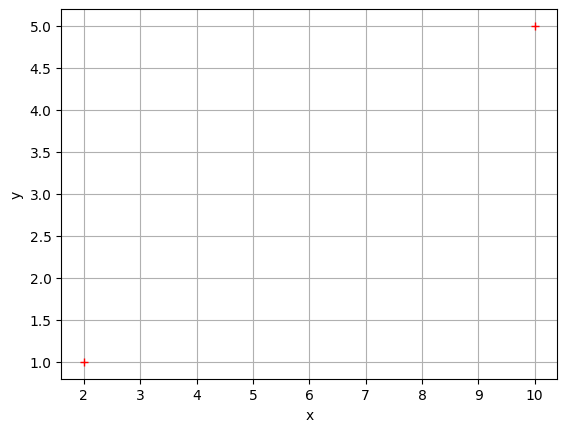

In [5]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

x = [2, 10]
y = [1, 5]

plt.plot(x, y, 'r+')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

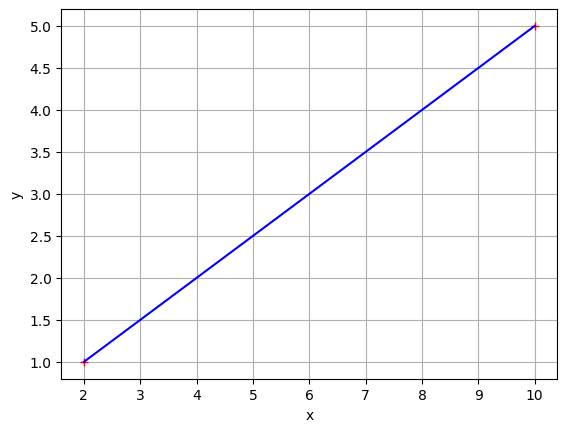

In [6]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

x = [2, 10]
y = [1, 5]

plt.plot(x, y, 'r+')
plt.plot(x, y, 'b-')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

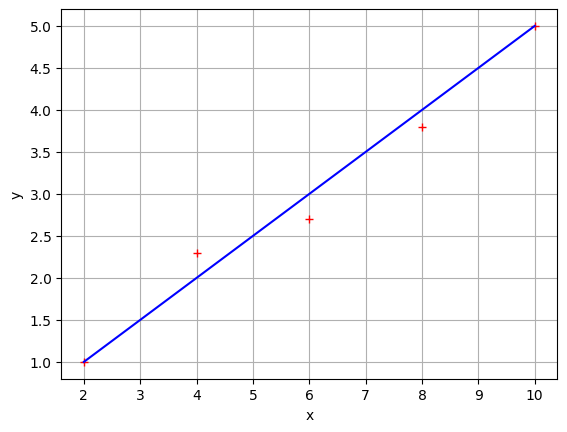

In [8]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

x = [2, 4, 6, 8, 10]
y = [1, 2.3, 2.7, 3.8, 5]

plt.plot(x, y, 'r+')
plt.plot([2,10], [1,5], 'b-')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

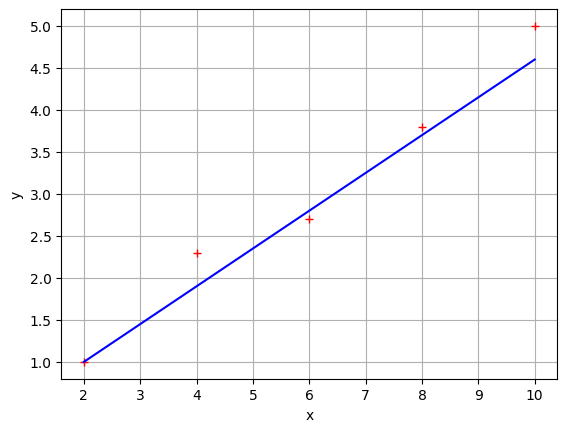

In [11]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

x = [2, 4, 6, 8, 10]
y = [1, 2.3, 2.7, 3.8, 5]

plt.plot(x, y, 'r+')
plt.plot([2,10], [2*0.45+0.1,10*0.45+0.1], 'b-')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

[0.11  0.475]


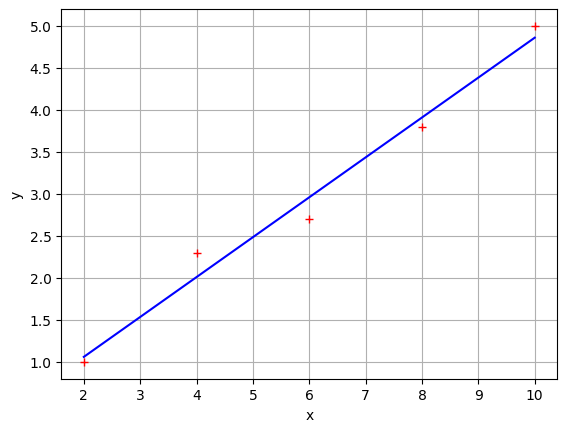

In [15]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

x = [2, 4, 6, 8, 10]
y = [1, 2.3, 2.7, 3.8, 5]

x_b = np.c_[np.ones((5,1)), x] # adiciona x0 = 1 em cada instância
theta_best = np.linalg.inv(x_b.T.dot(x_b)).dot(x_b.T).dot(y)
print(theta_best)

plt.plot(x, y, 'r+')
plt.plot([x[0], x[4]], [x[0] * theta_best[1] + theta_best[0], x[4] * theta_best[1] + theta_best[0]], 'b-')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [17]:
from sklearn.linear_model import LinearRegression

x = [2, 4, 6, 8, 10]
y = [1, 2.3, 2.7, 3.8, 5]

x_b = np.c_[np.ones((5,1)), x] # adiciona x0 = 1 em cada instância
lin_reg = LinearRegression()
lin_reg.fit(x_b, y)
lin_reg.intercept_, lin_reg.coef_

(np.float64(0.11000000000000032), array([0.   , 0.475]))

In [45]:
x = [2, 4, 6, 8, 10]
y = [1, 2.3, 2.7, 3.8, 5]
Y = np.array([y]).T

x_b = np.c_[np.ones((5,1)), x] # adiciona x0 = 1 em cada instância

eta = 0.01 # taxa de aprendizado
n_iterations = 2000
n = 5

theta = np.random.randn(2,1)
print("Chute inicial de theta: " + str(theta))

for interation in range(n_iterations):
  gradients = 2/n *(x_b.T.dot(x_b.dot(theta) - Y))
  theta = theta - eta * gradients

print("Valor final de theta: " + str(theta))

Chute inicial de theta: [[-0.07394574]
 [-1.25569479]]
Valor final de theta: [[0.11004076]
 [0.47499442]]


#Regressão Polinomial

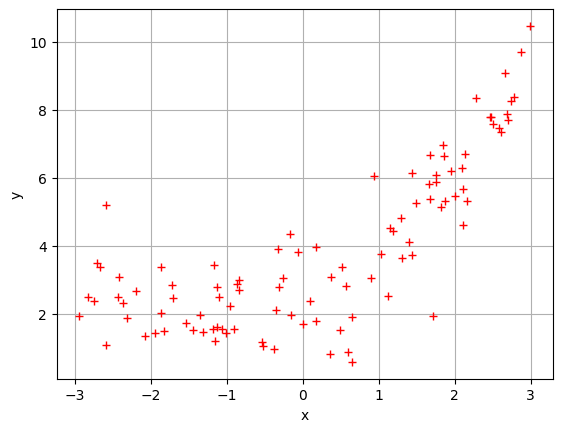

In [46]:
m = 100
x = 6 * np.random.rand(m, 1) - 3
y = 0.5 * x**2 + x + 2 + np.random.randn(m, 1)

plt.plot(x, y, 'r+')
plt.grid(True)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

[-1.72336704]
[-1.72336704  2.96999397]
[2.36275646] [[0.96939871 0.44267312]]


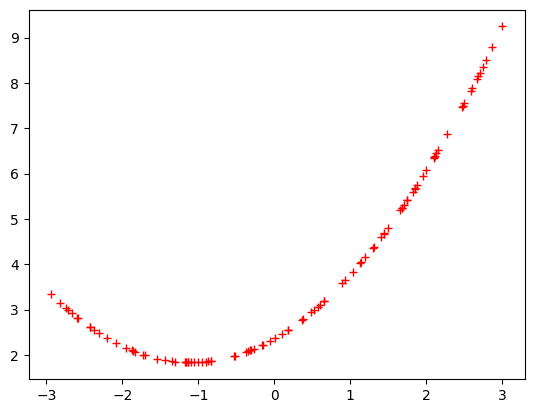

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly.fit_transform(x) # para obter x e x^2
print(x[0])
print(x_poly[0])

lin_reg = LinearRegression()
lin_reg.fit(x_poly, y)
print(lin_reg.intercept_, lin_reg.coef_)

x_poly.shape
plt.plot(x[0:], lin_reg.predict(x_poly), 'r+')

#Regresso Logística

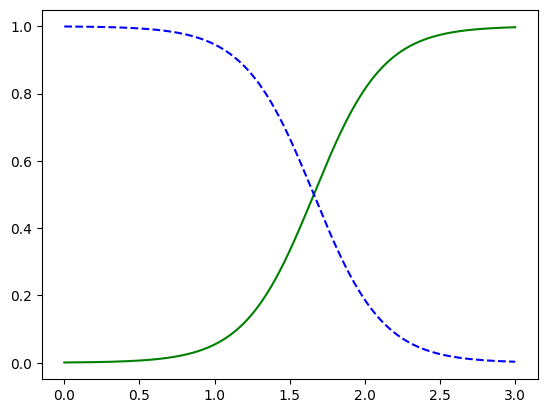

In [55]:
from sklearn import datasets
iris = datasets.load_iris()
list(iris.keys())

x = iris['data'][:, 3:] # largura da pétala
y = (iris['target'] == 2).astype(np.uint)  # 1 se Iris virginica, senão 0

from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(x, y)

x_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(x_new)
plt.plot(x_new, y_proba[:, 1], 'g-', label='Iris virginica')
plt.plot(x_new, y_proba[:, 0], 'b--', label='Não Iris virginica')
plt.show()

#Regresso logística multimodal

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


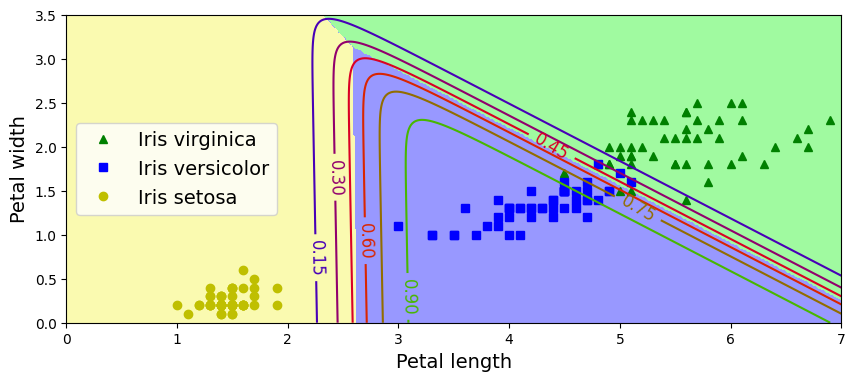

In [60]:
X = iris["data"][:, (2, 3)] # petal length, petal width
y = iris["target"]

softmax_reg = LogisticRegression(multi_class="multinomial",solver="lbfgs", C=10)
softmax_reg.fit(X, y)

x0, x1 = np.meshgrid(
        np.linspace(0, 8, 500).reshape(-1, 1),
        np.linspace(0, 3.5, 200).reshape(-1, 1),
    )
X_new = np.c_[x0.ravel(), x1.ravel()]


y_proba = softmax_reg.predict_proba(X_new)
y_predict = softmax_reg.predict(X_new)

zz1 = y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y==2, 0], X[y==2, 1], "g^", label="Iris virginica")
plt.plot(X[y==1, 0], X[y==1, 1], "bs", label="Iris versicolor")
plt.plot(X[y==0, 0], X[y==0, 1], "yo", label="Iris setosa")

from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap=plt.cm.brg)
plt.clabel(contour, inline=1, fontsize=12)
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="center left", fontsize=14)
plt.axis([0, 7, 0, 3.5])

plt.show()